# Sentiment Analysis on Amazon Product Reviews

## 1. Dataset Overview
- **Dataset Description**:
  - Analyze an Amazon product review dataset containing textual reviews (`reviewText`) and corresponding sentiment labels (`Positive`).
  - Sentiment is binary: 1 for positive, 0 for negative.
- **Objective**:
  - Predict the sentiment of a product review based on its textual content.


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB


In [57]:
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/refs/heads/main/amazon.csv'
df = pd.read_csv(url)
df.head()

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


## 2. Data Preprocessing
- Handle missing values, if any.
- Perform text preprocessing on the `reviewText` column:
  - Convert text to lowercase.
  - Remove stop words, punctuation, and special characters.
  - Tokenize and lemmatize text data.
- Split the dataset into training and testing sets.


In [58]:
df.info()
#there is no null value in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  20000 non-null  object
 1   Positive    20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


In [59]:
nltk.download('punkt')      # For tokenization
nltk.download('wordnet')    # For lemmatization
nltk.download('omw-1.4')    # For wordnet data
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [60]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [61]:
def preprocess(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation/special characters
    tokens = text.split()  # Tokenize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatize
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return " ".join(tokens)


In [62]:
# Apply preprocessing
cleaned_texts = [preprocess(t) for t in df['reviewText']]
df['reviewText'] = cleaned_texts
df.head()

,reviewText,Positive
0,one best apps acording bunch people agree ha b...,1
1,pretty good version game free lot different le...,1
2,really cool game bunch level find golden egg s...,1
3,silly game frustrating lot fun definitely reco...,1
4,terrific game pad hr fun grandkids love great ...,1


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    df['reviewText'],
    df['Positive'],
    test_size=0.2,
    random_state=42
)
X_train.shape


(16000,)

## 3. Model Selection
- Choose at least three machine learning models for sentiment classification:
  - Statistical Models:
    - Logistic Regression
    - Random Forest
    - Support Vector Machine (SVM)
    - Naïve Bayes
    - Gradient Boosting (e.g., XGBoost, AdaBoost, CatBoost)
  - Neural Models:
    - LSTM (Long Short-Term Memory)
    - GRUs (Gated Recurrent Units)


In [ ]:
def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    return model

In [80]:
def train_svm(X_train, y_train):
    model = SVC(random_state=42)
    model.fit(X_train, y_train)
    return model

In [91]:

def train_naive_bayes(X_train, y_train):
    model = MultinomialNB()
    model.fit(X_train, y_train)
    return model


## 4. Model Training
- Train each selected model on the training dataset.
- Utilize vectorization techniques for text data:
  - TF-IDF (Term Frequency-Inverse Document Frequency)
  - Word embeddings (e.g., Word2Vec, GloVe)


In [70]:

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english')
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)


In [76]:
randomForest = train_random_forest(X_train, y_train)

In [81]:
svm_model = train_svm(X_train, y_train)

In [92]:
naive_bayes_model = train_naive_bayes(X_train, y_train)

## 5. Formal Evaluation
- Evaluate the performance of each model on the testing set using the following metrics:
  - Accuracy
  - Precision
  - Recall
  - F1 Score
  - Confusion Matrix


In [88]:
y_pred_forest = randomForest.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred_forest)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, y_pred_forest)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred_forest)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, y_pred_forest)
print("F1 Score:", f1)



Accuracy: 0.867
Precision: 0.8697701826753094
Recall: 0.9704142011834319
F1 Score: 0.9173399627097576



Confusion Matrix:
 [[ 516  442]
 [  90 2952]]


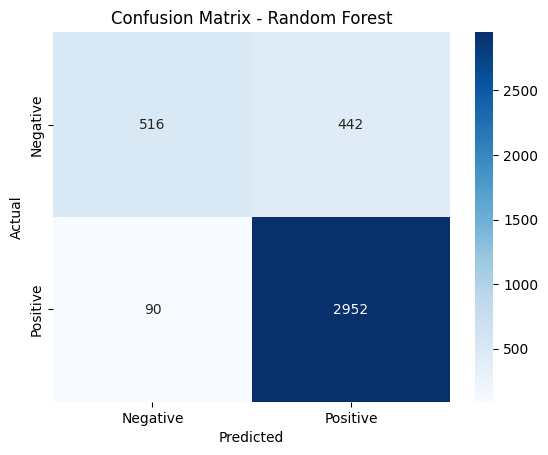

In [89]:
cm = confusion_matrix(y_test, y_pred_forest)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [84]:
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Precision:", precision_score(y_test, y_pred_svm))
print("SVM Recall:", recall_score(y_test, y_pred_svm))
print("SVM F1 Score:", f1_score(y_test, y_pred_svm))


SVM Accuracy: 0.8895
SVM Precision: 0.8973105134474327
SVM Recall: 0.965154503616042
SVM F1 Score: 0.9299968324358568



Confusion Matrix for SVM:
 [[ 622  336]
 [ 106 2936]]


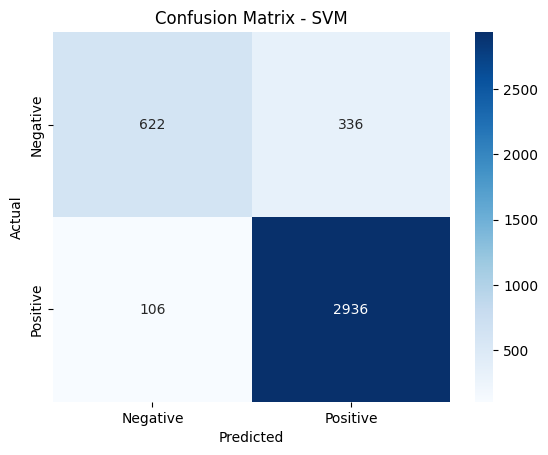

In [90]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix for SVM:\n", cm_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

In [94]:
y_pred_naive_bayes = naive_bayes_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_naive_bayes
))
print("Naive Bayes Precision:", precision_score(y_test, y_pred_naive_bayes))
print("Naive Bayes Recall:", recall_score(y_test, y_pred_naive_bayes))
print("Naive Bayes F1 Score:", f1_score(y_test, y_pred_naive_bayes))


Naive Bayes Accuracy: 0.79875
Naive Bayes Precision: 0.7921128231914338
Naive Bayes Recall: 0.9970414201183432
Naive Bayes F1 Score: 0.8828409256294572



Confusion Matrix for Naive Bayes:
 [[ 162  796]
 [   9 3033]]


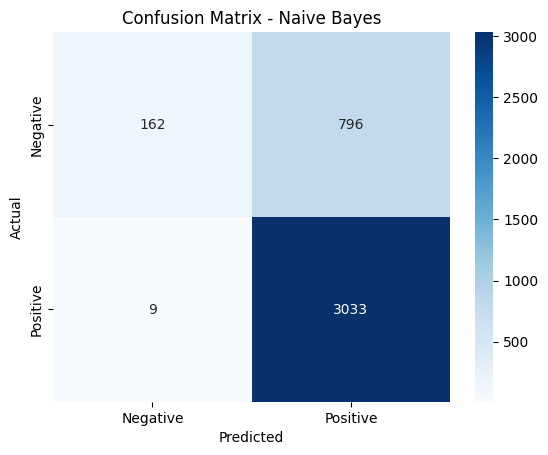

In [95]:
cm_naive_bayes = confusion_matrix(y_test, y_pred_naive_bayes)
print("\nConfusion Matrix for Naive Bayes:\n", cm_naive_bayes)
sns.heatmap(cm_naive_bayes, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

## 6. Hyperparameter Tuning
- Perform hyperparameter tuning for selected models using:
  - Grid Search
  - Random Search
- Explain the chosen hyperparameters and justify their selection.


## 7. Comparative Analysis
- Compare the performance of all models based on evaluation metrics.
- Identify strengths and weaknesses of each model (e.g., speed, accuracy, interpretability).


## 8. Conclusion & Comments
- Summarize the findings of the project.
- Provide insights into the challenges faced during data preprocessing, model training, and evaluation.
- Highlight key lessons learned.
- Add clear and concise comments to the code for each step of the project.
- Highlight key results, visualizations, and model comparisons.
